In [1]:
# LabOne Q:
from laboneq.simple import *
# pretty printing
from pprint import pprint
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation
import numpy as np

## Device Setup

In [2]:
def create_device_setup(descriptor):
    device_setup=DeviceSetup.from_descriptor(descriptor, server_host="10.42.193.4",server_port="8004",setup_name="myFirstSetup")
    #calibrate_devices(device_setup)
    return device_setup

In [17]:
def calibrate_devices(device_setup):
    device_setup.logical_signal_groups["q0"].logical_signals["AOM_line"].calibration = SignalCalibration(
        oscillator=Oscillator(
            uid="drive_AOM", frequency=10e6, modulation_type=ModulationType.HARDWARE
        ),
        mixer_calibration=MixerCalibration(
            voltage_offsets=[0.0, 0.0],
            correction_matrix=[
                [1.0, 0.0],
                [0.0, 1.0],
            ],
        ),
    )
    
    device_setup.logical_signal_groups["q1"].logical_signals["TTU_line"].calibration = SignalCalibration(
        oscillator=Oscillator(
            uid = "drive_TTU", frequency=10e6, modulation_type=ModulationType.HARDWARE
        ),)
    
    device_setup.logical_signal_groups["q2"].logical_signals["MW_line"].calibration = SignalCalibration(
        oscillator=Oscillator(
            uid = "drive_MW", frequency=200e6, modulation_type=ModulationType.HARDWARE
        ),)
        

In [18]:
# create device setup
my_device_setup = DeviceSetup("my_device_setup")
my_device_setup.add_dataserver(host = "10.42.193.4", port = "8004")

# add instruments
my_device_setup.add_instruments(HDAWG(uid="device_hdawg", address="dev8297",device_options='HDAWG8/CNT/ME/MF/PC'))

# add connections
my_device_setup.add_connections(
    "device_hdawg",
    create_connection(to_signal="q0/AOM_line", ports=["SIGOUTS/0"], type='rf'),
    create_connection(to_signal="q1/TTU_line", ports=["SIGOUTS/1"], type='rf'),
    create_connection(to_signal="q2/MW_line", ports=["SIGOUTS/2"], type='rf'),
)

# set baseline calibration
calibrate_devices(my_device_setup)

In [19]:
#device_setup=create_device_setup(descriptor)
session=Session(device_setup=my_device_setup)
session.connect(do_emulation=False, ignore_version_mismatch=True)

[2026.02.26 10:14:38.865] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/avishekc/Library/CloudStorage/OneDrive-ZurichInstrumentsAG/Documents/ZI Python/Toolkit/QT/laboneq_output/log
[2026.02.26 10:14:38.874] INFO    VERSION: laboneq 25.10.2
[2026.02.26 10:14:38.876] INFO    Connecting to data server at 10.42.193.4:8004
[2026.02.26 10:14:38.882] INFO    Connected to Zurich Instruments LabOne Data Server version 26.01.0.361 at 10.42.193.4:8004
[2026.02.26 10:14:38.883] WARNING Ignoring that Version of LabOne Python API (25.10.1.4) is older than LabOne Data Server (26.01.0.361). You can install a matching or newer version of the LabOne Python API with: pip install --upgrade zhinst-core~=26.1.0
[2026.02.26 10:14:38.890] INFO    Configuring the device setup
[2026.02.26 10:14:38.899] INFO    The device setup is configured


## Pulses and Sweep parameters

In [20]:
amplitude_sweep = LinearSweepParameter(
    uid="amplitude",
    start = 0.1,
    stop = 1.0,
    count = 5
)

## Define main experiment

In [ ]:
def amplitude_rabi(amplitude_sweep):

    exp_rabi=Experiment(
        uid="Amplitude Rabi",
        signals=[
            ExperimentSignal("AOM"),
            ExperimentSignal("TTU"),
            ExperimentSignal("MW"),
        ],
    )

    with exp_rabi.acquire_loop_rt(
        count = 1,
        averaging_mode=AveragingMode.CYCLIC,
        acquisition_type = AcquisitionType.INTEGRATION,
    ):
        with exp_rabi.sweep( uid ='sweep',
                        parameter= amplitude_sweep
                        ):
            # section 1: Play the trigger#1 to the laser
                
            with exp_rabi.section(
                uid="AOM",
                alignment=SectionAlignment.LEFT,
                length=10e-6,
                ):
                exp_rabi.play(
                    signal="AOM",
                    pulse=pulse_library.const(length=4000e-09,amplitude=1),
                    marker={"marker1": {"enable": True}},
                    )
                
                exp_rabi.delay(signal="AOM",time=2000e-9)

                exp_rabi.play(
                    signal="AOM",
                    pulse=pulse_library.const(length=2000e-09,amplitude=1),
                    marker={"marker1": {"enable": True}},
                )


            with exp_rabi.section(
                uid="TTU",
                alignment=SectionAlignment.LEFT,
                length=10e-6, 
                #trigger={"drive":{"state":1}},          
            ):
                exp_rabi.delay(signal="TTU",time=5000e-9)

                exp_rabi.play(
                    signal="TTU",
                    pulse=pulse_library.const(length=2000e-09,amplitude=1),
                    marker={"marker1": {"enable": True}},
                )

            #with exp_rabi.section(
            #    uid="MW",
            #    alignment=SectionAlignment.LEFT,
            #    length=10e-6, 
            #    #trigger={"drive":{"state":1}},          
            #):
            #    exp_rabi.delay(signal="MW",time=5000e-9)

            #    exp_rabi.play(
            #        signal="MW",
            #        pulse=pulse_library.gaussian(length=1000e-09,amplitude=1),
            #        marker={"marker1": {"enable": True}},
            #    )
            
            with exp_rabi.section(
                uid="MW",
                alignment=SectionAlignment.LEFT,
                length=10e-6,
            ):  
                exp_rabi.delay(signal="MW",time=4000e-9)

                exp_rabi.play(
                    signal="MW",
                    pulse=pulse_library.gaussian(length=100e-09),
                    amplitude=amplitude_sweep,
                    marker={"marker1": {"enable": True}},
                )

                exp_rabi.delay(signal="MW",time=100e-9)
            
                
    return exp_rabi

## Create signal map

In [42]:
signal_map={
    "AOM":my_device_setup.logical_signal_groups["q0"].logical_signals["AOM_line"],
    "TTU":my_device_setup.logical_signal_groups["q1"].logical_signals["TTU_line"],
    "MW":my_device_setup.logical_signal_groups["q2"].logical_signals["MW_line"],
    }

calib_q0=Calibration()

## Compile the experiment

In [43]:
calibrate_devices(my_device_setup)

rabi_exp=amplitude_rabi(amplitude_sweep)

rabi_exp.set_signal_map(signal_map)

compiled_rabi=session.compile(rabi_exp)

res_rabi=session.run(compiled_rabi)

[2026.02.26 12:00:29.175] INFO    Starting LabOne Q Compiler run...
[2026.02.26 12:00:29.181] INFO    Schedule completed. [0.002 s]
[2026.02.26 12:00:29.187] INFO    Code generation completed for all AWGs. [0.004 s]
[2026.02.26 12:00:29.187] INFO    Completed compilation step 1 of 1. [0.008 s]
[2026.02.26 12:00:29.189] INFO     ────────────────────────────────────────────────────────────────── 
[2026.02.26 12:00:29.190] INFO      Device         AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.02.26 12:00:29.190] INFO     ────────────────────────────────────────────────────────────────── 
[2026.02.26 12:00:29.190] INFO      device_hdawg     0         15            3           2     33600  
[2026.02.26 12:00:29.191] INFO      device_hdawg     1         16            4           1       240  
[2026.02.26 12:00:29.192] INFO     ────────────────────────────────────────────────────────────────── 
[2026.02.26 12:00:29.193] INFO      TOTAL                      31            7         

## Plot simulation

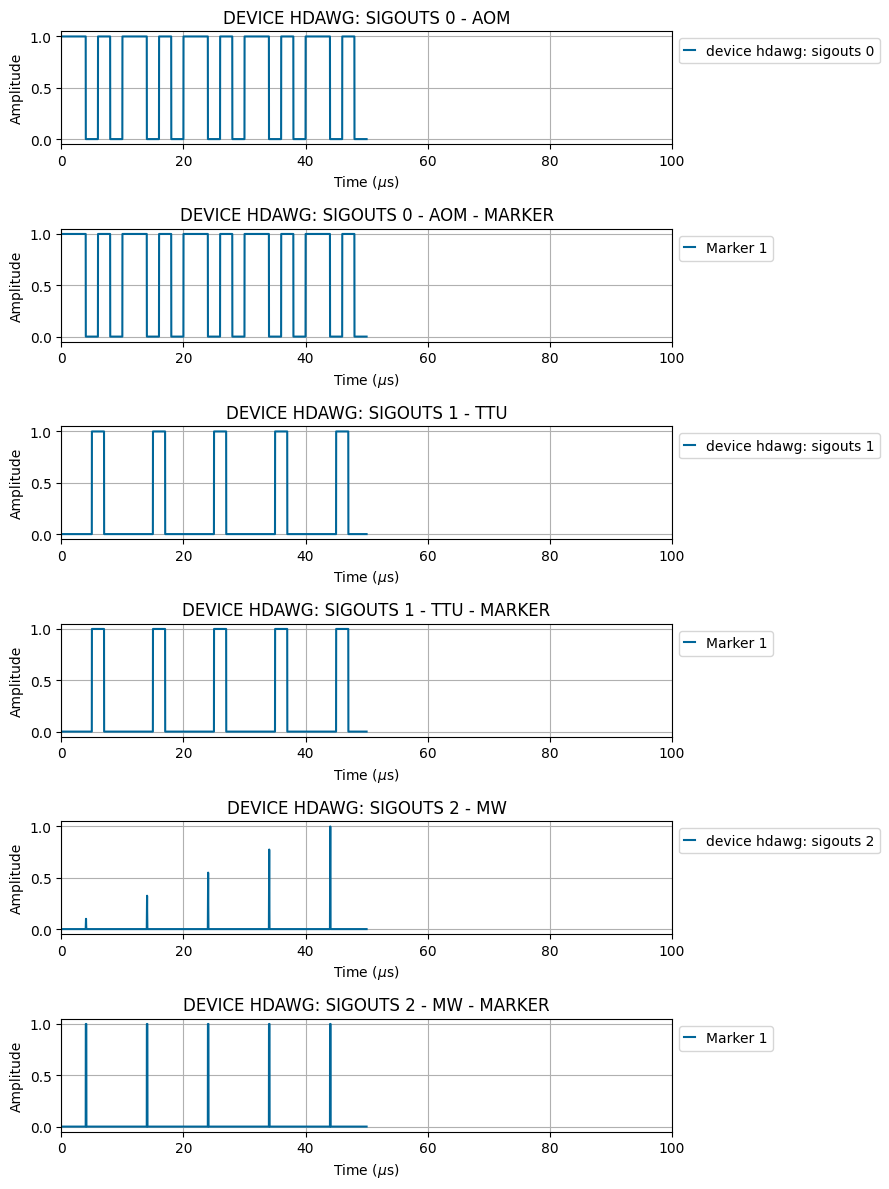

In [44]:
plot_simulation(compiled_rabi,start_time=0e-6,length=100e-6)

In [33]:
show_pulse_sheet("Ramsey_Experiment",compiled_rabi)

[2026.02.25 16:25:04.494] INFO    Recompiling the experiment due to missing extra information in the compiled experiment. Compile with `OUTPUT_EXTRAS=True` and `MAX_EVENTS_TO_PUBLISH=1000` to bypass this step with a small impact on the compilation time.
[2026.02.25 16:25:04.496] INFO    Starting LabOne Q Compiler run...
[2026.02.25 16:25:04.499] INFO    Schedule completed. [0.001 s]
[2026.02.25 16:25:04.502] INFO    Code generation completed for all AWGs. [0.002 s]
[2026.02.25 16:25:04.503] INFO    Completed compilation step 1 of 1. [0.004 s]
[2026.02.25 16:25:04.503] WARNING /opt/miniconda3/lib/python3.13/site-packages/laboneq/core/utilities/seqc_compile.py:42: UserWarning: Installed version of zhinst-seqc-compiler is not compatible with this version of zhinst.core. Falling back to own version.
  elf, extra = zhinst.core.compile_seqc(

[2026.02.25 16:25:04.506] INFO    Finished LabOne Q Compiler run.
[2026.02.25 16:25:04.652] INFO    Writing html file to /Users/avishekc/Library/CloudS

/Users/avishekc/Library/CloudStorage/OneDrive-ZurichInstrumentsAG/Documents/ZI Python/Toolkit/QT/Ramsey_Experiment_2026-02-25-16-25-04.html